# NBA Spread Prediction — EDA and Results

This notebook is the visual companion to the project [README](../README.md).
It reads the processed CSVs produced by the feature-engineering pipeline and
the held-out test evaluation to surface the findings that the README describes
in prose — cover-rate balance, feature distributions, model importance, and
the flat-betting backtest results.
All charts use data that was already written to disk; no pipeline code is
re-executed here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

# Works whether the notebook is executed via nbconvert from the project root
# or opened interactively from the notebooks/ directory.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
DATA_DIR  = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

SEASON_LABELS = {2021: "2020-21", 2022: "2021-22", 2023: "2022-23",
                 2024: "2023-24", 2025: "2024-25"}

print("Project root:", PROJECT_ROOT)
print("Pandas:", pd.__version__, " | Matplotlib:", plt.matplotlib.__version__,
      " | XGBoost:", xgb.__version__)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/abhinavsharma/nba-betting-engine
Pandas: 3.0.3  | Matplotlib: 3.11.0  | XGBoost: 3.3.0


## 1. Spread Cover Rate by Season

The home team covered the spread in roughly half of all games in each season.
This near-50/50 split is expected: sportsbooks set lines to split the public
bet volume, keeping the market efficient. It also means a model must beat
**52.38%** (the break-even rate at −110 odds) to be profitable — roughly
2–3 percentage points above the baseline rate. That bar is much higher
than it initially appears.

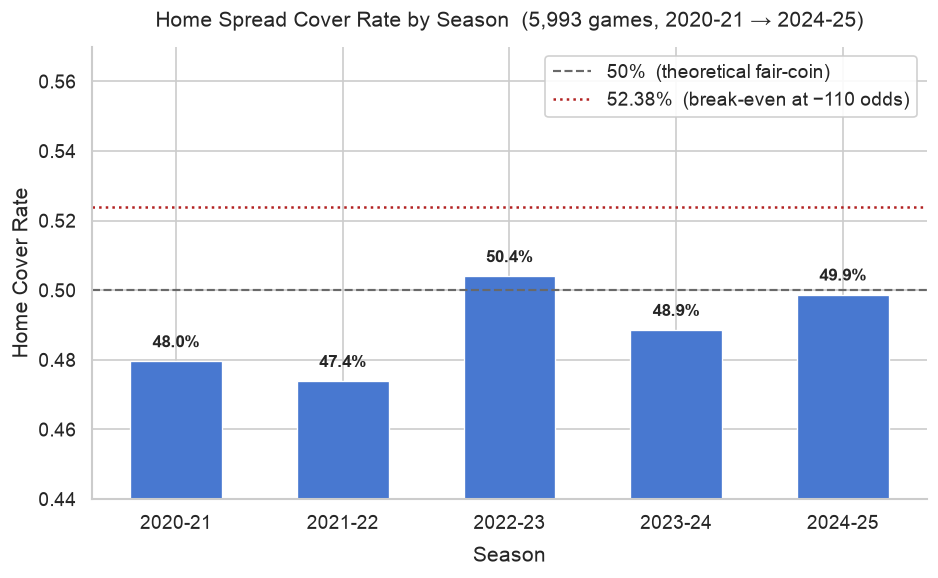

In [2]:
fm = pd.read_csv(DATA_DIR / "feature_matrix.csv")
fm["season_label"] = fm["season"].map(SEASON_LABELS)

cover = fm.groupby("season_label")["home_covers_spread"].mean().reset_index()
cover.columns = ["Season", "Home Cover Rate"]

palette = sns.color_palette("muted")
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(cover["Season"], cover["Home Cover Rate"],
              color=palette[0], edgecolor="white", linewidth=0.8, width=0.55)

ax.axhline(0.5,    color="dimgray",  linestyle="--", linewidth=1.3,
           label="50%  (theoretical fair-coin)")
ax.axhline(0.5238, color="firebrick", linestyle=":",  linewidth=1.5,
           label="52.38%  (break-even at −110 odds)")

for bar, rate in zip(bars, cover["Home Cover Rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0.44, 0.57)
ax.set_xlabel("Season", labelpad=8)
ax.set_ylabel("Home Cover Rate")
ax.set_title("Home Spread Cover Rate by Season  (5,993 games, 2020-21 → 2024-25)",
             pad=12)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 2. Rolling Offensive Rating Distribution

`rolling_ortg_10_home` is the home team's offensive rating (points per 100
possessions, Dean Oliver estimate) averaged over the 10 games immediately
preceding each matchup. Real NBA teams cluster between roughly 105 and 120
with a league average around 110–113. The distribution below confirms the
pipeline is computing ORtg in the right numerical range — the plausibility
check we ran in Phase 2 in text form, now visible as a histogram.

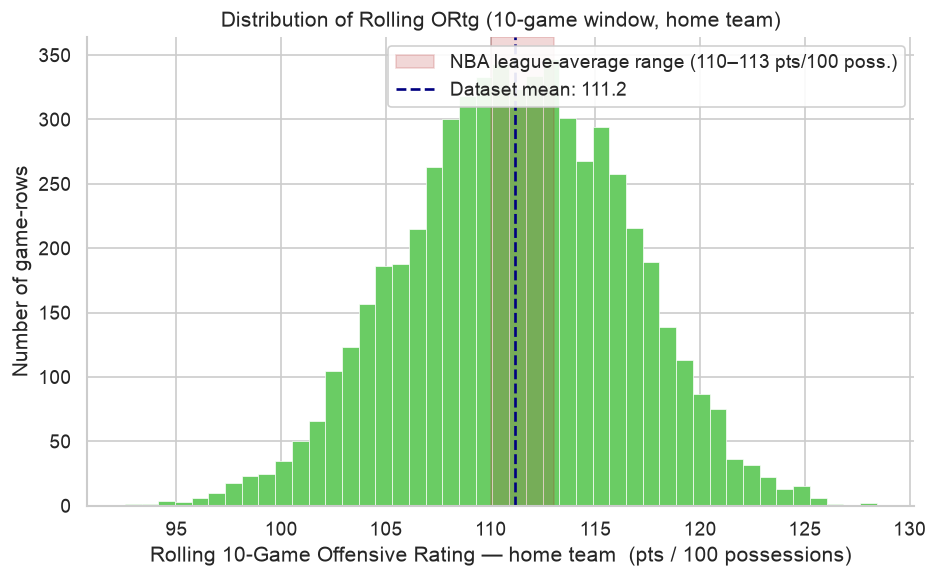

In [3]:
ortg = fm["rolling_ortg_10_home"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ortg, bins=45, color=palette[2], edgecolor="white", linewidth=0.4)

ax.axvspan(110, 113, alpha=0.18, color="firebrick",
           label="NBA league-average range (110–113 pts/100 poss.)")
ax.axvline(ortg.mean(), color="navy", linestyle="--", linewidth=1.6,
           label=f"Dataset mean: {ortg.mean():.1f}")

ax.set_xlabel("Rolling 10-Game Offensive Rating — home team  (pts / 100 possessions)")
ax.set_ylabel("Number of game-rows")
ax.set_title("Distribution of Rolling ORtg (10-game window, home team)")
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

## 3. Feature Importance — Top 15

XGBoost assigns an importance score to each feature based on how often it
is used as a split point across all trees (the *weight* metric). The chart
below shows the 15 most-used features in the tuned model. Note that high
importance does not imply good predictive power — a feature the model
leans on heavily can still produce near-random predictions if the underlying
signal is weak, which is consistent with the ROC-AUC result we found in
Phase 3.

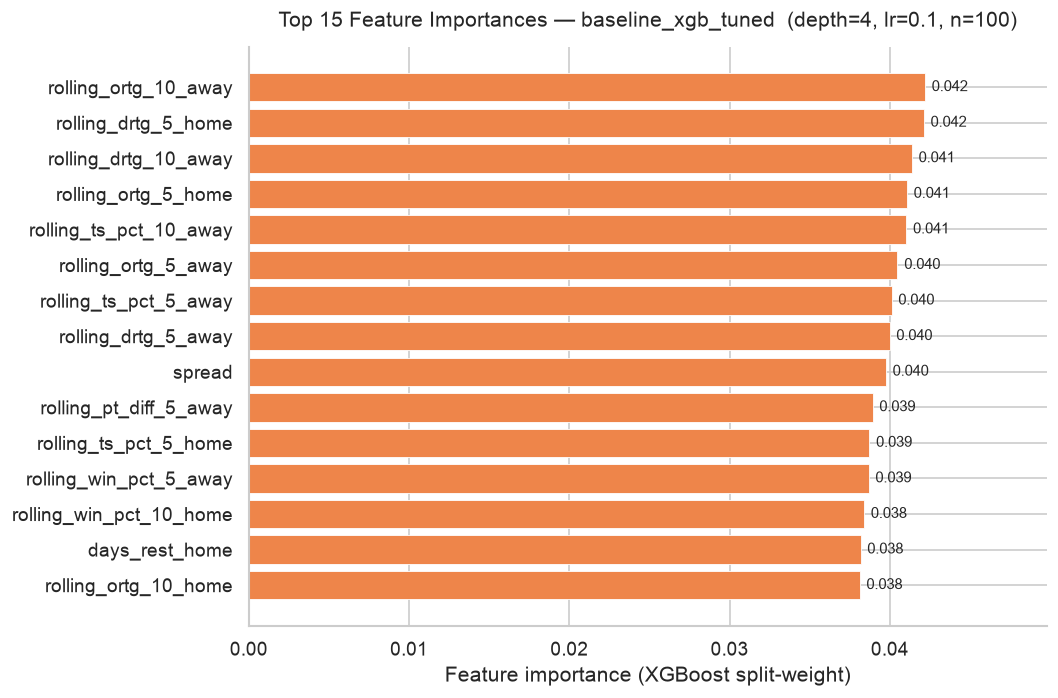

In [4]:
model = xgb.XGBClassifier()
model.load_model(str(MODEL_DIR / "baseline_xgb_tuned.json"))

# Feature names are stored in the saved model; fall back to the known
# v1 training column order if they are absent.
booster = model.get_booster()
feature_names = booster.feature_names or [
    "rolling_win_pct_5_home",   "rolling_win_pct_10_home",
    "rolling_pt_diff_5_home",   "rolling_pt_diff_10_home",
    "days_rest_home",           "is_back_to_back_home",
    "rolling_ortg_5_home",      "rolling_ortg_10_home",
    "rolling_drtg_5_home",      "rolling_drtg_10_home",
    "rolling_ts_pct_5_home",    "rolling_ts_pct_10_home",
    "rolling_win_pct_5_away",   "rolling_win_pct_10_away",
    "rolling_pt_diff_5_away",   "rolling_pt_diff_10_away",
    "days_rest_away",           "is_back_to_back_away",
    "rolling_ortg_5_away",      "rolling_ortg_10_away",
    "rolling_drtg_5_away",      "rolling_drtg_10_away",
    "rolling_ts_pct_5_away",    "rolling_ts_pct_10_away",
    "recent_injuries_count_home", "recent_injuries_count_away", "has_injury_data",
    "spread", "total",
]

importances = pd.Series(model.feature_importances_, index=feature_names)
top15 = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index, top15.values, color=palette[1],
               edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, top15.values):
    ax.text(val + top15.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_xlim(0, top15.max() * 1.18)
ax.set_xlabel("Feature importance (XGBoost split-weight)")
ax.set_title("Top 15 Feature Importances — baseline_xgb_tuned  (depth=4, lr=0.1, n=100)",
             pad=12)
plt.tight_layout()
plt.show()

## 4. Flat-Betting Backtest — ROI by Strategy

Simulating $100 flat bets on every 2024-25 game at standard −110 odds
(win: +$90.91, lose: −$100.00). The break-even win rate is 52.38%;
ROI = 0% corresponds exactly to that threshold. All three strategies fall
below it — the model is the weakest performer, which is consistent with
the ROC-AUC of 0.479 (slightly below random). The three strategies cluster
within ≈1.4 percentage points of each other, well within sampling noise for
1,225 games.

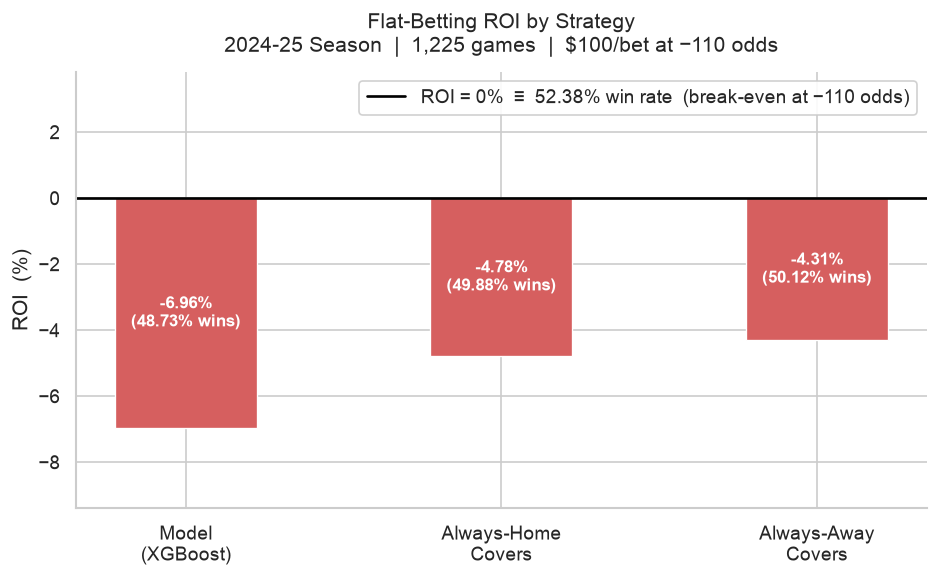

In [5]:
backtest = pd.read_csv(DATA_DIR / "backtest_summary.csv")

short_labels = ["Model\n(XGBoost)", "Always-Home\nCovers", "Always-Away\nCovers"]
rois   = backtest["roi_pct"].tolist()
wins   = backtest["win_rate_pct"].tolist()

bar_colors = [palette[3] if r < 0 else palette[2] for r in rois]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(short_labels, rois, color=bar_colors,
              edgecolor="white", linewidth=0.8, width=0.45)

ax.axhline(0, color="black", linewidth=1.6,
           label="ROI = 0%  ≡  52.38% win rate  (break-even at −110 odds)")

for bar, roi, win in zip(bars, rois, wins):
    # Label inside bar: ROI %, with win rate below
    mid = roi / 2
    ax.text(bar.get_x() + bar.get_width() / 2, mid,
            f"{roi:.2f}%\n({win:.2f}% wins)",
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.set_ylabel("ROI  (%)")
ax.set_ylim(min(rois) * 1.35, abs(min(rois)) * 0.55)
ax.set_title("Flat-Betting ROI by Strategy\n2024-25 Season  |  1,225 games  |  $100/bet at −110 odds",
             pad=12)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## Summary

Across five seasons of NBA data, rolling team-form and efficiency features
produced a model that performs at near-random on the held-out 2024-25 season
(ROC-AUC 0.479, accuracy 48.73%), and no flat-betting strategy — model or
naive — cleared the 52.38% break-even threshold required to profit at −110
odds. This is an honest, rigorously-obtained empirical finding: NBA closing
lines are highly efficient and the features tested here do not carry a
statistically significant signal above what the market has already priced in.

For the full quantitative detail see the
[Backtest Results](../README.md#backtest-results-2024-25-held-out-test-season)
and [Feature Ablation Study](../README.md#feature-ablation-study) sections
of the README.